In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [ ]:
# Define paths (CHANGE THIS to your actual path)
train_path = "/content/drive/MyDrive/train"
test_path = "/content/drive/MyDrive/test"

# Count images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")

# YOUR CODE HERE: Print the number of test images
# Hint: Look at the code above and modify it for test_path

test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Test hot dog images: {test_hot_dog_count}")
print(f"Test not hot dog images: {test_not_hot_dog_count}")

Hot dog images: 249
Not hot dog images: 249
Test hot dog images: 250
Test not hot dog images: 250


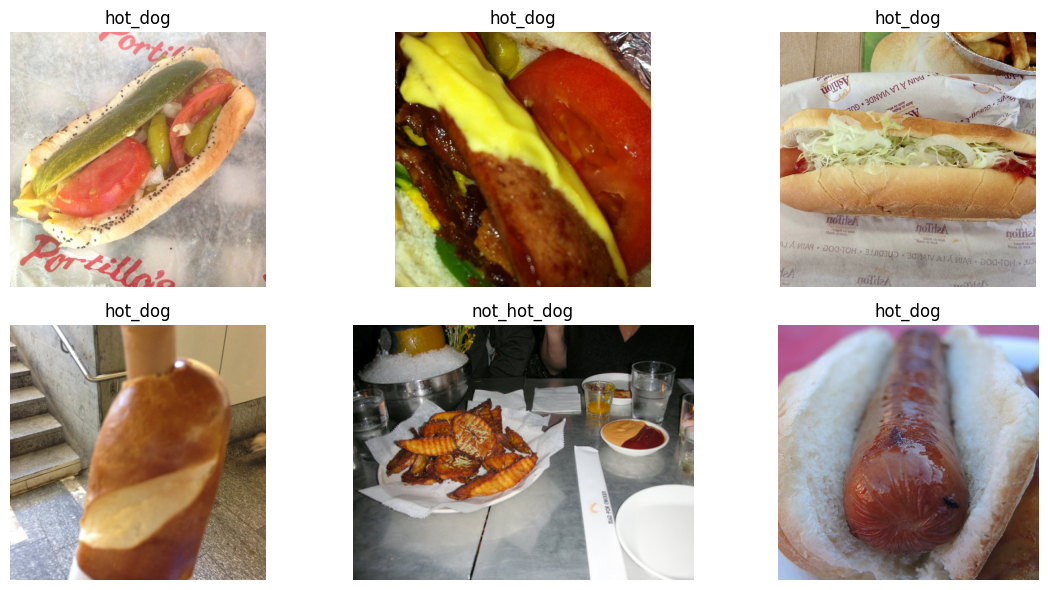

Image shape: (501, 512, 3)


In [ ]:
# Display 6 random images
plt.figure(figsize=(12, 6))

for i in range(6):

    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and show image
    img = plt.imread(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


print("Image shape:", img.shape)

In [ ]:
# Set image size (YOUR CHOICE: 64x64 is faster, 128x128 is more accurate)
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32

# Create generators with automatic labeling
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values from 0-255 to 0-1
    validation_split=0.2  # Use 20% of training data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',  # Binary classification (hot dog vs not)
    subset='training'  # Training set (80% of data)
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'  # Validation set (20% of data)
)

# YOUR CODE HERE: Print the class labels
# Hint: Print train_generator.class_indices

print(train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
{'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 142s 11s/step - accuracy: 0.4775 - loss: 1.5251 - val_accuracy: 0.5306 - val_loss: 0.7355
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.5900 - loss: 0.6845 - val_accuracy: 0.5816 - val_loss: 0.7065
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.6675 - loss: 0.6307 - val_accuracy: 0.5612 - val_loss: 0.7312
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.7000 - loss: 0.5753 - val_accuracy: 0.5816 - val_loss: 0.7155
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 0.7450 - loss: 0.5276 - val_accuracy: 0.5000 - val_loss: 0.7610
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.7500 - loss: 0.5237 - val_accuracy: 0.5306 - val_loss: 0.7472
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.7875 - loss: 0.4943 - val_accuracy: 0.5204 - val_loss: 0.8131
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.7450 - loss: 0.5324 - val_accuracy: 0.

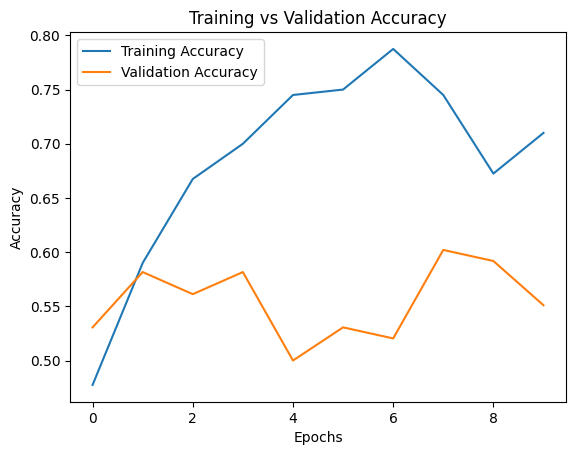

In [ ]:
# Build a simple ANN
ann_model = keras.Sequential([

    # Flatten the 2D image into 1D
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')  # Output: probability of "hot dog"
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
ann_model.summary()

# Train for 10 epochs
history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# YOUR CODE HERE: Plot training vs validation accuracy

plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# Build a CNN
cnn_model = keras.Sequential([

    # First Conv layer: 32 filters, 3x3 kernel
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv layer: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Conv layer (YOUR TURN): Add 64 filters with 3x3 kernel,
    # followed by Max pooling

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile (copy from ANN)

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the CNN
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step - accuracy: 0.5100 - loss: 0.6975 - val_accuracy: 0.5306 - val_loss: 0.6898
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step - accuracy: 0.5425 - loss: 0.6890 - val_accuracy: 0.5000 - val_loss: 0.7001
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.5400 - loss: 0.6815 - val_accuracy: 0.5612 - val_loss: 0.6737
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - accuracy: 0.6500 - loss: 0.6419 - val_accuracy: 0.6224 - val_loss: 0.6734
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.6825 - loss: 0.5988 - val_accuracy: 0.5918 - val_loss: 0.6712
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step - accuracy: 0.7275 - loss: 0.5579 - val_accuracy: 0.5612 - val_loss: 0.6761
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.7750 - loss: 0.5027 - val_accuracy: 0.6122 - val_loss: 0.7719
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - accuracy: 0.7900 - loss: 0.4641 - val_accuracy: 0.

In [ ]:
from tensorflow.keras import regularizers

# Add dropout of 0.25, 0.25, and 0.5 after each MaxPooling layer respectively
improved_model = keras.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Add dropout

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Add dropout

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),  # Add dropout before output

    layers.Dense(1, activation='sigmoid')
])

# Recompile and Train the improved model
improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - accuracy: 0.4900 - loss: 0.7137 - val_accuracy: 0.5816 - val_loss: 0.6925
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 317ms/step - accuracy: 0.5300 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.5225 - loss: 0.6950 - val_accuracy: 0.6122 - val_loss: 0.6924
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.5550 - loss: 0.6912 - val_accuracy: 0.5306 - val_loss: 0.6908
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.5750 - loss: 0.6799 - val_accuracy: 0.6020 - val_loss: 0.6785
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - accuracy: 0.6075 - loss: 0.6714 - val_accuracy: 0.5918 - val_loss: 0.6664
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.6300 - loss: 0.6571 - val_accuracy: 0.6122 - val_loss: 0.6657
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.5950 - loss: 0.6492 - val_accuracy: 0.

In [ ]:
# 8.2 Fix2: Add Data Augmentation

# Modify the ImageDataGenerator to create more variations
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Then retrain the improved model with augmented_datagen
final_model = keras.Sequential([

    # Same architecture as improved_model
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = final_model.fit(
    train_augmented,
    validation_data=validation_generator,
    epochs=15
)

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 400ms/step - accuracy: 0.4725 - loss: 0.7135 - val_accuracy: 0.5102 - val_loss: 0.6923
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.5675 - loss: 0.6890 - val_accuracy: 0.5306 - val_loss: 0.6917
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step - accuracy: 0.5150 - loss: 0.6912 - val_accuracy: 0.5510 - val_loss: 0.6900
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 352ms/step - accuracy: 0.5400 - loss: 0.6892 - val_accuracy: 0.5714 - val_loss: 0.6870
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.5700 - loss: 0.6847 - val_accuracy: 0.5612 - val_loss: 0.6860
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 293ms/step - accuracy: 0.5900 - loss: 0.6751 - val_accuracy: 0.5204 - val_loss: 0.6914
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 361ms/step - accuracy: 0.5775 - loss: 0.6815 - val_accuracy: 0.5204 - val_loss: 0.6895
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step - accuracy:

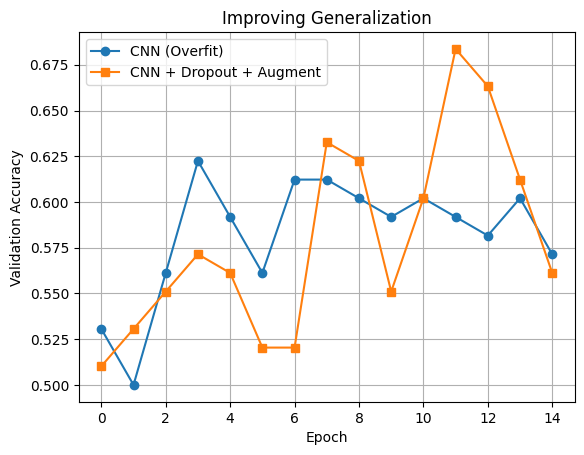

In [ ]:
plt.plot(history_cnn.history['val_accuracy'],
         label='CNN (Overfit)',
         marker='o')

plt.plot(history_final.history['val_accuracy'],
         label='CNN + Dropout + Augment',
         marker='s')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

plt.legend()
plt.title('Improving Generalization')
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
 NOT A HOT DOG! (confidence: 0.43)


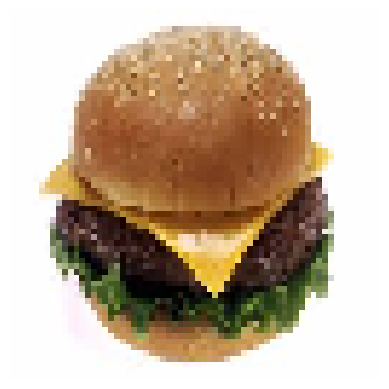

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image(img_path):

    # Load image from local disk
    img = image.load_img(
        img_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = final_model.predict(img_array)[0][0]

    if prediction > 0.7:
        print(f" HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f" NOT A HOT DOG! (confidence: {1 - prediction:.2f})")

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.show()


# Test on local image (CHANGE PATH)
predict_image("/content/bb.jfif")


image 1/1 /content/ppp.jpg: 576x640 1 truck, 2 pizzas, 412.1ms
Speed: 16.2ms preprocess, 412.1ms inference, 59.8ms postprocess per image at shape (1, 3, 576, 640)


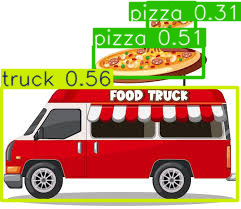

In [ ]:
# Install correct package
!pip install ultralytics

from ultralytics import YOLO

# Load pre-trained YOLO model
yolo_model = YOLO("yolov8n.pt")

# Run detection on your image
results = yolo_model("/content/ppp.jpg")  # recommended: use .jpg or .png

# Show results with bounding boxes
results[0].show()

In [ ]:
!jupyter nbconvert --to html //content/Aliraza6.ipynb

[NbConvertApp] Converting notebook //content/Aliraza6.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1600202 bytes to //content/Aliraza6.html


In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf //content/Aliraza6.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
[NbConvertApp] Converting notebook //content/Aliraza6.ipynb to pdf
[NbConvertApp] Support files will be in Aliraza6_files/
[NbConvertApp] Making directory ./Aliraza6_files
[NbConvertApp] Writing 87440 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 911964 bytes to //content/Aliraza6.pdf
